# Onevoice Healthcare Solution: Data Pipeline & EDA
Notebook này được thiết kế để chạy trên **Google Colab Pro** nhằm tải toàn bộ dữ liệu âm thanh và văn bản y tế có dung lượng lớn, sau đó thực hiện Khám phá dữ liệu (EDA).

## Hướng dẫn Kaggle
Hãy đảm bảo bạn đã upload file `kaggle.json` vào Colab (hoặc mount Google Drive) để có thể tải dataset từ Kaggle.

In [ ]:
!pip install -q datasets huggingface_hub kaggle librosa matplotlib seaborn soundfile pandas

In [ ]:
import os
# Thiết lập Kaggle API (Yêu cầu upload file kaggle.json lên môi trường Colab)
if not os.path.exists('/root/.kaggle/kaggle.json'):
    !mkdir -p ~/.kaggle
    print('Vui lòng upload file kaggle.json vào thư mục hiện tại.')
    from google.colab import files
    uploaded = files.upload()
    for fn in uploaded.keys():
        !cp {fn} ~/.kaggle/kaggle.json
    !chmod 600 ~/.kaggle/kaggle.json

Vui lòng upload file kaggle.json vào thư mục hiện tại.


Saving kaggle.json to kaggle.json


In [ ]:
import os
import subprocess
from datasets import load_dataset, Dataset

DATA_DIR = "/content/datasets"
os.makedirs(DATA_DIR, exist_ok=True)

def download_hf_dataset(repo_id, name, split="train"):
    print(f"\n--- Tải {repo_id} ---")
    local_path = os.path.join(DATA_DIR, name)
    ds = load_dataset(repo_id, split=split)
    ds.save_to_disk(local_path)
    print(f"Đã lưu tại {local_path}")

def download_kaggle_dataset(dataset_id, name):
    print(f"\n--- Tải Kaggle: {dataset_id} ---")
    local_path = os.path.join(DATA_DIR, name)
    os.makedirs(local_path, exist_ok=True)
    !kaggle datasets download -d {dataset_id} -p {local_path} --unzip
    print(f"Đã lưu tại {local_path}")

print("Bắt đầu kéo dữ liệu... có thể mất vài chục phút tùy dung lượng.")
download_hf_dataset("hungsvdut2k2/vietnamese-medical-chat-data", "vietnamese_medical_chat", split="train")
download_hf_dataset("tensorxt/ViMedCSS", "vimedcss", split="train")
download_hf_dataset("leduckhai/VietMed", "vietmed_full", split="test") # Tải full thay vì subset
download_hf_dataset("ekacare/eka-medical-asr-evaluation-dataset", "eka_medical_asr", split="test")
download_kaggle_dataset("paultimothymooney/medical-speech-transcription-and-intent", "kaggle_medical_speech")


Bắt đầu kéo dữ liệu... có thể mất vài chục phút tùy dung lượng.

--- Tải hungsvdut2k2/vietnamese-medical-chat-data ---


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/355 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/28.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/46479 [00:00<?, ? examples/s]

...

en/test-00006.parquet:   0%|          | 0.00/63.1M [00:00<?, ?B/s]

en/test-00007.parquet:   0%|          | 0.00/15.8M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/3619 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/3619 [00:00<?, ? examples/s]

Đã lưu tại /content/datasets/eka_medical_asr

--- Tải Kaggle: paultimothymooney/medical-speech-transcription-and-intent ---
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/medical-speech-transcription-and-intent
License(s): other
100% 5.27G/5.27G [01:01<00:00, 92.5MB/s]

Đã lưu tại /content/datasets/kaggle_medical_speech



=== EDA Text: Medical Chat (Text) ===
Số lượng mẫu: 46479


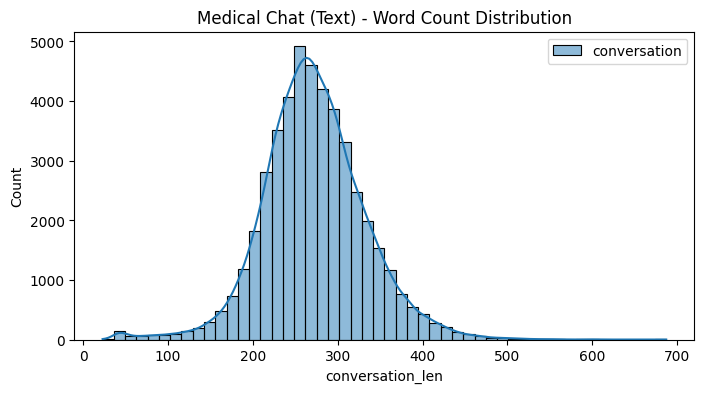


=== EDA Audio: ViMedCSS (Audio) ===


Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]

Tổng số mẫu: 11832
Tính toán độ dài cho 1000 mẫu ngẫu nhiên...


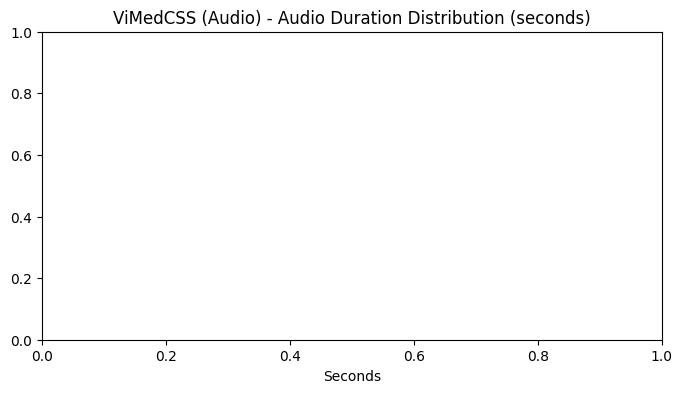


=== EDA Audio: VietMed (Audio) ===
Tổng số mẫu: 3437
Tính toán độ dài cho 1000 mẫu ngẫu nhiên...


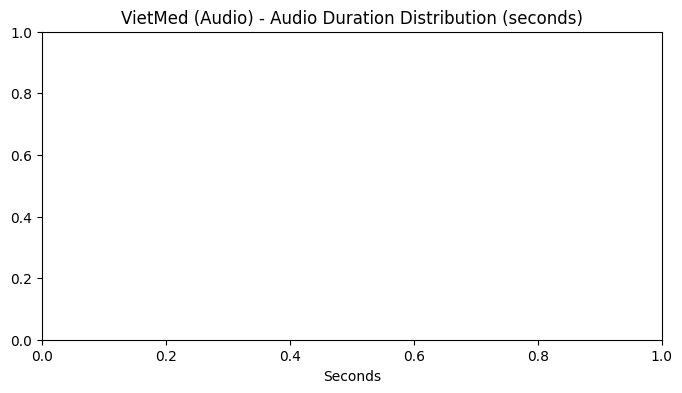


=== EDA Audio: Eka ASR (Audio) ===
Tổng số mẫu: 3619
Tính toán độ dài cho 1000 mẫu ngẫu nhiên...


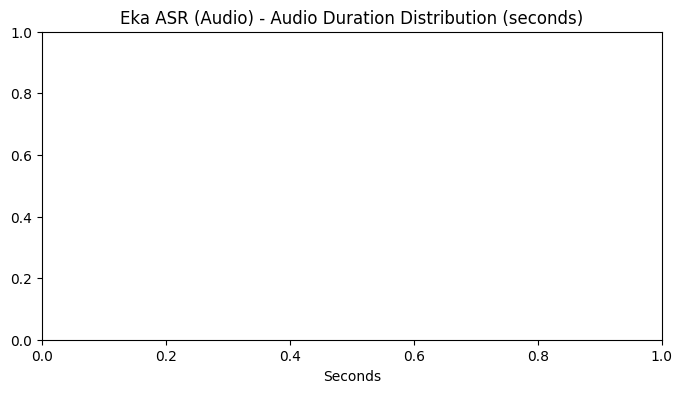

In [ ]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_from_disk
import librosa
from pathlib import Path

def eda_text(path, name):
    print(f"\n=== EDA Text: {name} ===")
    try:
        ds = load_from_disk(path)
        print(f"Số lượng mẫu: {len(ds)}")
        df = ds.to_pandas()
        text_cols = [c for c in df.columns if df[c].dtype == 'object'][:2]
        for col in text_cols:
            df[f'{col}_len'] = df[col].astype(str).apply(lambda x: len(x.split()))

        if text_cols:
            plt.figure(figsize=(8, 4))
            for col in text_cols:
                sns.histplot(df[f'{col}_len'], kde=True, label=col, bins=50)
            plt.title(f"{name} - Word Count Distribution")
            plt.legend()
            plt.show()
    except Exception as e:
        print("Lỗi:", e)

def eda_audio(path, name, sample_limit=1000):
    print(f"\n=== EDA Audio: {name} ===")
    try:
        ds = load_from_disk(path)
        print(f"Tổng số mẫu: {len(ds)}")

        audio_col = next((c for c, f in ds.features.items() if hasattr(f, 'sampling_rate') or 'audio' in c.lower()), None)
        if not audio_col: return

        durations = []
        sample_size = min(sample_limit, len(ds))
        print(f"Tính toán độ dài cho {sample_size} mẫu ngẫu nhiên...")
        for i in range(sample_size):
            item = ds[i][audio_col]
            if isinstance(item, dict) and 'array' in item and 'sampling_rate' in item:
                durations.append(len(item['array']) / item['sampling_rate'])

        plt.figure(figsize=(8, 4))
        sns.histplot(durations, kde=True, bins=50, color='coral')
        plt.title(f"{name} - Audio Duration Distribution (seconds)")
        plt.xlabel("Seconds")
        plt.show()
    except Exception as e:
        print("Lỗi:", e)

eda_text(f"{DATA_DIR}/vietnamese_medical_chat", "Medical Chat (Text)")
eda_audio(f"{DATA_DIR}/vimedcss", "ViMedCSS (Audio)")
eda_audio(f"{DATA_DIR}/vietmed_full", "VietMed (Audio)")
eda_audio(f"{DATA_DIR}/eka_medical_asr", "Eka ASR (Audio)")


=== Advanced EDA: Text Dataset ===
Cột 'conversation': Có 0 mẫu bị rỗng/thiếu.


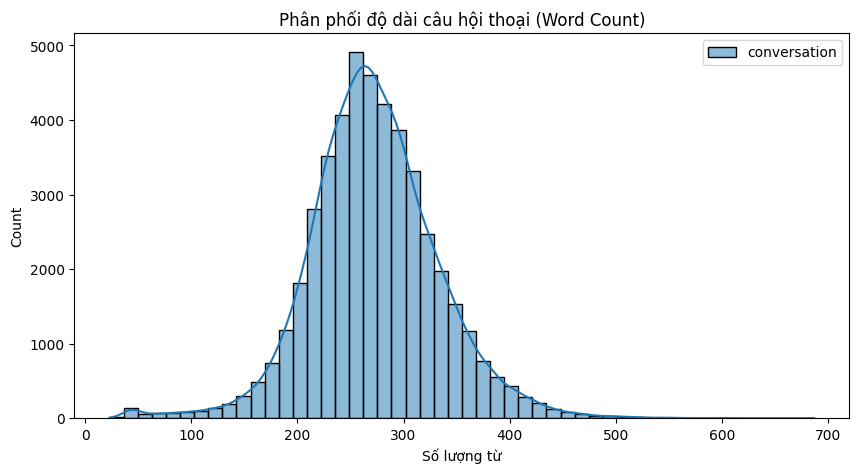

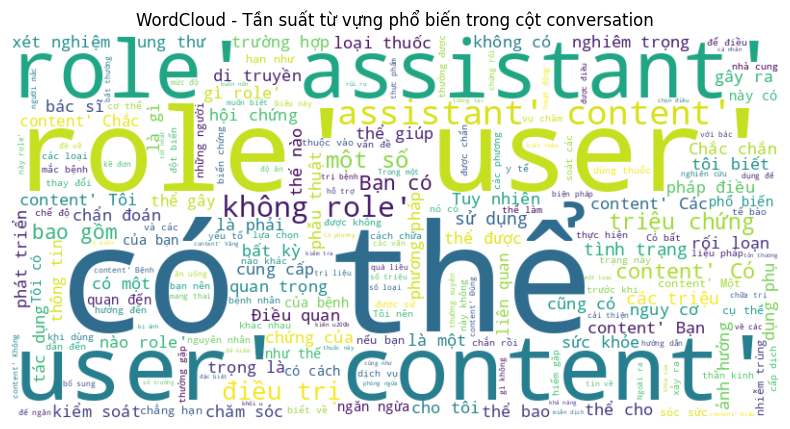

In [ ]:
!pip install -q wordcloud
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from datasets import load_from_disk
import os

DATA_DIR = "/content/datasets"

print("=== Advanced EDA: Text Dataset ===")
ds_text = load_from_disk(f"{DATA_DIR}/vietnamese_medical_chat")
df_text = ds_text.to_pandas()

# Tìm cột chứa Text
text_cols = [c for c in df_text.columns if df_text[c].dtype == 'object'][:2]

# Phân tích phân phối độ dài & Dữ liệu rỗng
for col in text_cols:
    df_text[f'{col}_len'] = df_text[col].astype(str).apply(lambda x: len(x.split()))
    # Đã fix lỗi Array Ambiguous bằng cách ép kiểu chuỗi an toàn
    empty_count = df_text[col].isnull().sum() + (df_text[col].astype(str).str.strip() == '').sum()
    print(f"Cột '{col}': Có {empty_count} mẫu bị rỗng/thiếu.")

plt.figure(figsize=(10, 5))
for col in text_cols:
    sns.histplot(df_text[f'{col}_len'], kde=True, label=col, bins=50)
plt.title("Phân phối độ dài câu hội thoại (Word Count)")
plt.xlabel("Số lượng từ")
plt.legend()
plt.show()

# Phân tích từ vựng phổ biến (WordCloud)
if text_cols:
    all_text = " ".join(df_text[text_cols[0]].astype(str).tolist())
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - Tần suất từ vựng phổ biến trong cột {text_cols[0]}")
    plt.show()



=== Advanced EDA Audio: ViMedCSS (Code-switching) ===


Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]

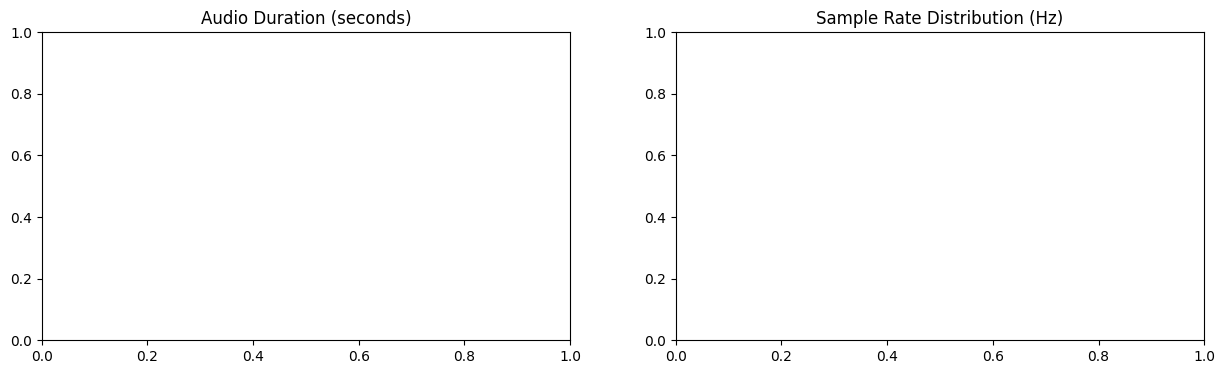


--- Trực quan hóa Mẫu âm thanh đầu tiên của ViMedCSS (Code-switching) ---
Lỗi: 'array'

=== Advanced EDA Audio: VietMed (Vietnamese ASR) ===


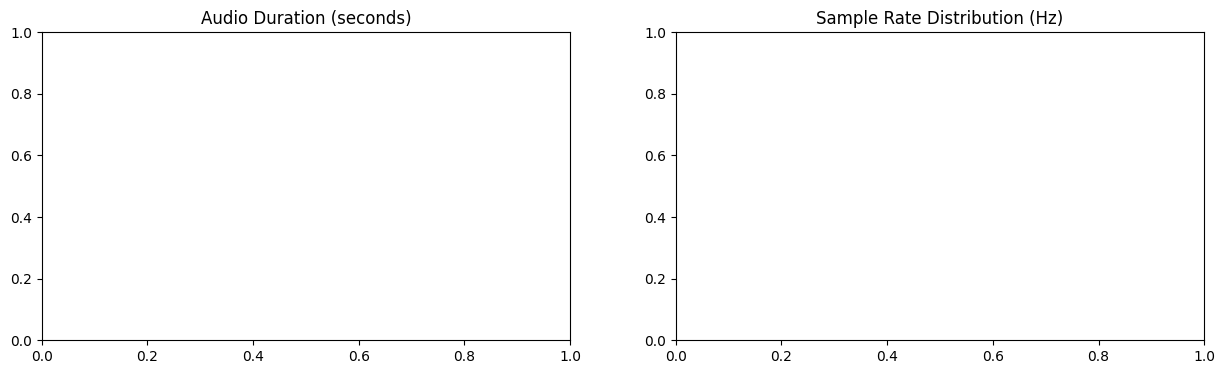


--- Trực quan hóa Mẫu âm thanh đầu tiên của VietMed (Vietnamese ASR) ---


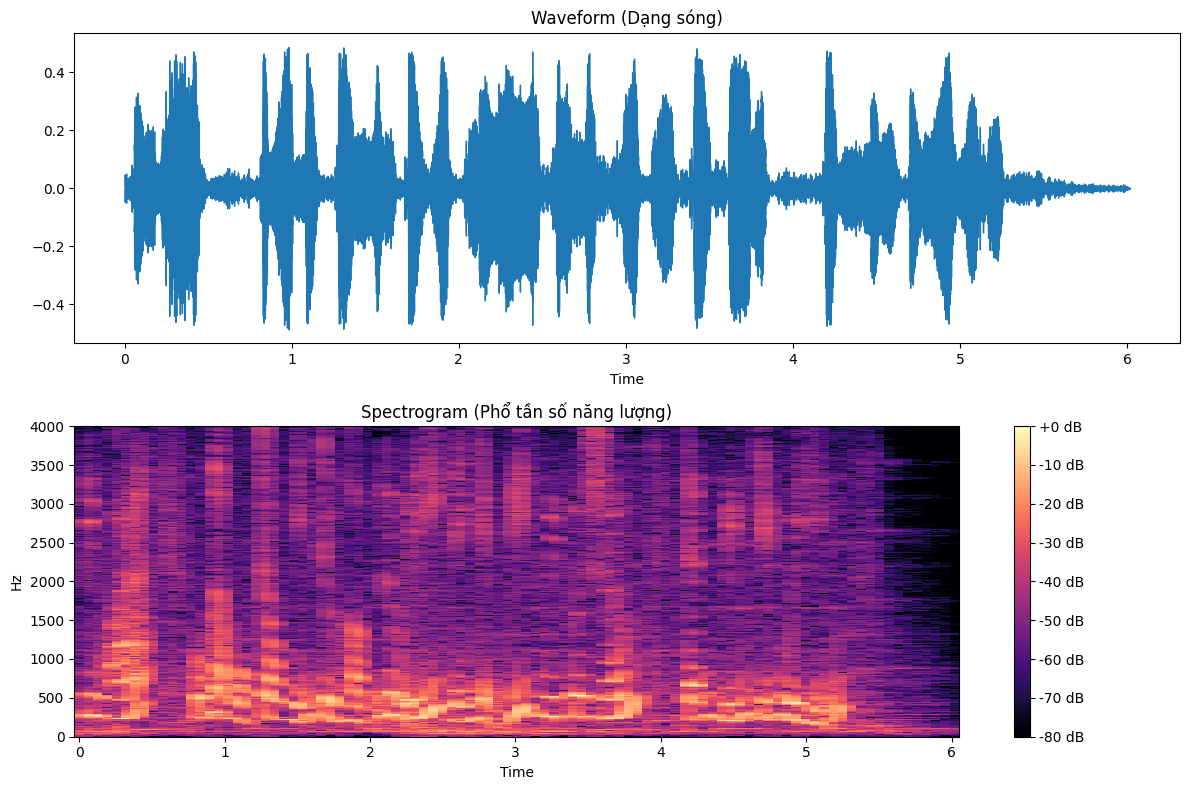


=== Advanced EDA Audio: Eka ASR (English) ===


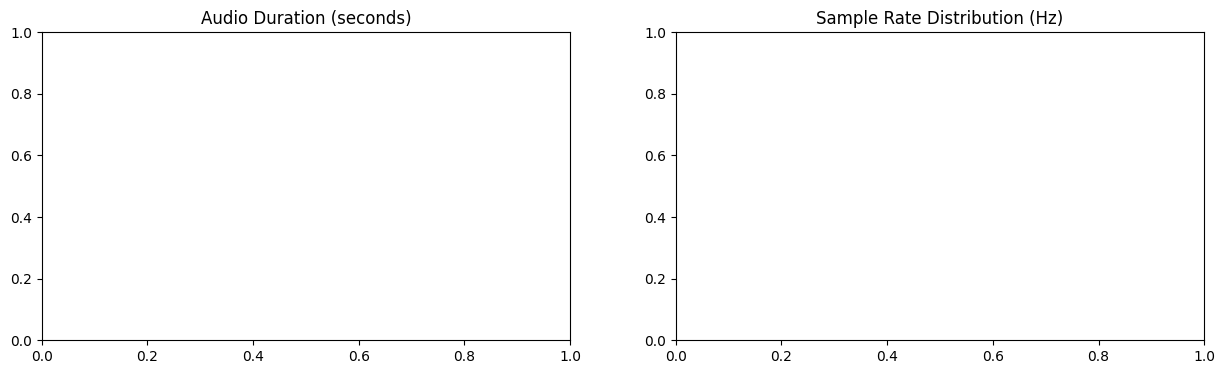


--- Trực quan hóa Mẫu âm thanh đầu tiên của Eka ASR (English) ---


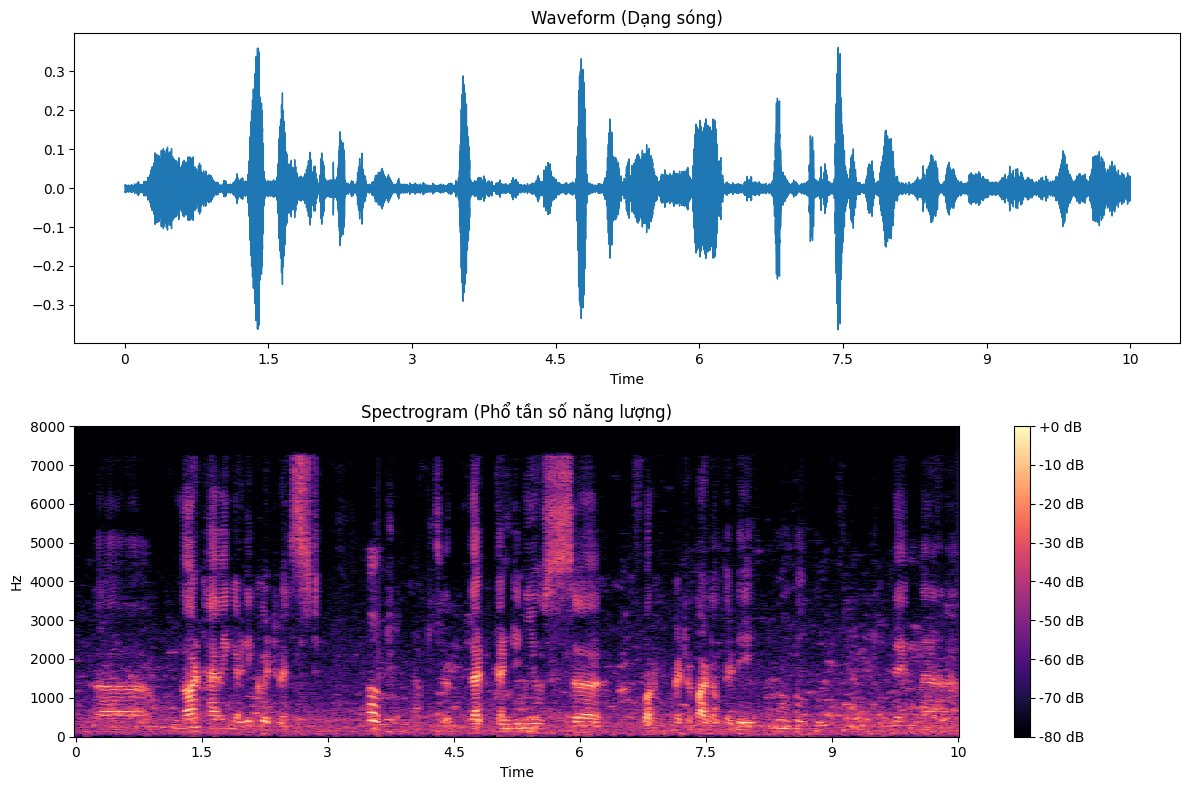

In [ ]:
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_from_disk

def advanced_audio_eda(path, name, sample_limit=500):
    print(f"\n==========================================")
    print(f"=== Advanced EDA Audio: {name} ===")
    try:
        ds = load_from_disk(path)

        audio_col = next((c for c, f in ds.features.items() if hasattr(f, 'sampling_rate') or 'audio' in c.lower()), None)
        text_col = next((c for c in ds.features.keys() if 'text' in c.lower() or 'transcript' in c.lower()), None)
        if not audio_col: return

        durations = []
        sample_rates = []
        speech_rates = []

        sample_size = min(sample_limit, len(ds))
        for i in range(sample_size):
            item = ds[i][audio_col]
            if isinstance(item, dict) and 'array' in item and 'sampling_rate' in item:
                dur = len(item['array']) / item['sampling_rate']
                durations.append(dur)
                sample_rates.append(item['sampling_rate'])

                if text_col and ds[i][text_col]:
                    char_count = len(str(ds[i][text_col]))
                    if dur > 0:
                        speech_rates.append(char_count / dur)

        # 1. Phân phối độ dài Audio & Sample Rate
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        sns.histplot(durations, kde=True, bins=50, color='coral', ax=axes[0])
        axes[0].set_title("Audio Duration (seconds)")

        sns.countplot(x=sample_rates, ax=axes[1], palette='viridis')
        axes[1].set_title("Sample Rate Distribution (Hz)")
        plt.show()

        # 2. Phân phối tốc độ nói (Characters per second)
        if speech_rates:
            plt.figure(figsize=(8, 4))
            sns.histplot(speech_rates, kde=True, bins=50, color='purple')
            plt.title("Tốc độ nói (Characters / Second)")
            plt.show()

        # 3. Phân tích Tín hiệu chuyên sâu (Waveform & Spectrogram) trên 1 mẫu ngẫu nhiên
        print(f"\n--- Trực quan hóa Mẫu âm thanh đầu tiên của {name} ---")
        sample_audio = ds[0][audio_col]['array']
        sample_sr = ds[0][audio_col]['sampling_rate']

        fig, ax = plt.subplots(2, 1, figsize=(12, 8))
        # Waveform
        librosa.display.waveshow(sample_audio, sr=sample_sr, ax=ax[0])
        ax[0].set_title("Waveform (Dạng sóng)")

        # Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(sample_audio)), ref=np.max)
        img = librosa.display.specshow(D, y_axis='linear', x_axis='time', sr=sample_sr, ax=ax[1])
        fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
        ax[1].set_title("Spectrogram (Phổ tần số năng lượng)")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("Lỗi:", e)

DATA_DIR = "/content/datasets"
advanced_audio_eda(f"{DATA_DIR}/vimedcss", "ViMedCSS (Code-switching)")
advanced_audio_eda(f"{DATA_DIR}/vietmed_full", "VietMed (Vietnamese ASR)")
advanced_audio_eda(f"{DATA_DIR}/eka_medical_asr", "Eka ASR (English)")
